# 07. Price prediction evaluation

Deep-dive on the RandomForest model saved by notebook 06. Six analyses:

1. **Monthly AUC stability** — does the model hold up month-by-month on the test window, or decay toward random?
2. **Per-ticker AUC** — are the gains uniform across the universe, or concentrated in a handful of tickers?
3. **Model-vs-delta edge profile** — when the model disagrees with the market's delta, who's closer to the empirical truth?
4. **Calibration per (type, OTM)** — beyond aggregated calibration from 06, is each individual slice well-calibrated?
5. **Platt scaling** — fit a LogisticRegression on train-set predictions to sharpen calibration, save the production-ready bundle.
6. **Decision-threshold analysis** — if you only trade the lowest-quintile P(filled) candidates, what's your actual fill rate? Translates AUC into an actionable filter.

All analysis is on the pre-computed `data/price_model_predictions.parquet` from 06 — no retraining needed.

In [1]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import brier_score_loss, roc_auc_score


PREDICTIONS_PATH = Path("output/08_price_prediction_modeling/price_model_predictions.parquet")
FEATURES_PATH = Path("output/07_price_prediction_feature_engineering/price_features.parquet")
LABELS_PATH = Path("output/03_weekly_strategy_labels/strategy_labels.parquet")
MODEL_PATH = Path("output/08_price_prediction_modeling/price_model.pkl")
CALIBRATED_MODEL_OUT = Path("output/09_price_prediction_evaluation/price_model_calibrated.pkl")
OUT_DIR = Path("output/09_price_prediction_evaluation")
OUT_DIR.mkdir(parents=True, exist_ok=True)
OTM_THRESHOLDS = [0.01, 0.02, 0.03, 0.04, 0.05]

## Load predictions + model

In [2]:
preds = pd.read_parquet(PREDICTIONS_PATH)
preds["monday_date"] = pd.to_datetime(preds["monday_date"])
features = pd.read_parquet(FEATURES_PATH)
features["monday_date"] = pd.to_datetime(features["monday_date"])
labels = pd.read_parquet(LABELS_PATH)
labels["monday_date"] = pd.to_datetime(labels["monday_date"])
model_artifact = joblib.load(MODEL_PATH)
rf = model_artifact["model"]
model_name = model_artifact["name"]
FEATURE_NAMES = model_artifact["feature_names"]

# Use RF predictions as "model" for this evaluation
preds = preds.rename(columns={"rf_proba": "model_proba"})
preds["month"] = preds["monday_date"].dt.to_period("M").astype(str)

print(f"model: {model_name}")
print(f"predictions: {len(preds):,} rows, {preds['month'].nunique()} test months")

model: RandomForest
predictions: 13,390 rows, 10 test months


## 1. Monthly AUC stability

Does the model's edge persist over time, or degrade as the market regime changes? Reported AUC per test month for both CC and CSP, alongside the delta baseline.

In [3]:
stability_rows = []
for month, mdf in preds.groupby("month"):
    for type_code, type_key in [(1, "CC"), (0, "CSP")]:
        sub = mdf[mdf["type_cc"] == type_code]
        if len(sub) < 100:
            continue
        y = sub["filled"].values
        auc_model = roc_auc_score(y, sub["model_proba"].values)
        delta_keep = ~sub["p_mkt_filled"].isna()
        auc_delta = (
            roc_auc_score(y[delta_keep], sub["p_mkt_filled"].values[delta_keep])
            if delta_keep.sum() >= 50
            else None
        )
        stability_rows.append(
            {
                "month": month,
                "type": type_key,
                "n": len(sub),
                "auc_model": round(auc_model, 4),
                "auc_delta": round(auc_delta, 4) if auc_delta is not None else None,
                "edge": round(auc_model - auc_delta, 4)
                if auc_delta is not None
                else None,
            }
        )
stability = pd.DataFrame(stability_rows)
stability

,month,type,n,auc_model,auc_delta,edge
0,2025-06,CC,675,0.5613,0.5388,0.0224
1,2025-06,CSP,675,0.7240,0.6214,0.1027
2,2025-07,CC,680,0.6638,0.5597,0.1041
3,2025-07,CSP,680,0.6559,0.6382,0.0177
4,2025-08,CC,685,0.6096,0.6638,-0.0542
5,2025-08,CSP,685,0.6633,0.6258,0.0375
6,2025-09,CC,680,0.6785,0.6587,0.0198
7,2025-09,CSP,680,0.6458,0.6117,0.0341
8,2025-10,CC,680,0.5988,0.5959,0.0029
9,2025-10,CSP,680,0.6858,0.6641,0.0217


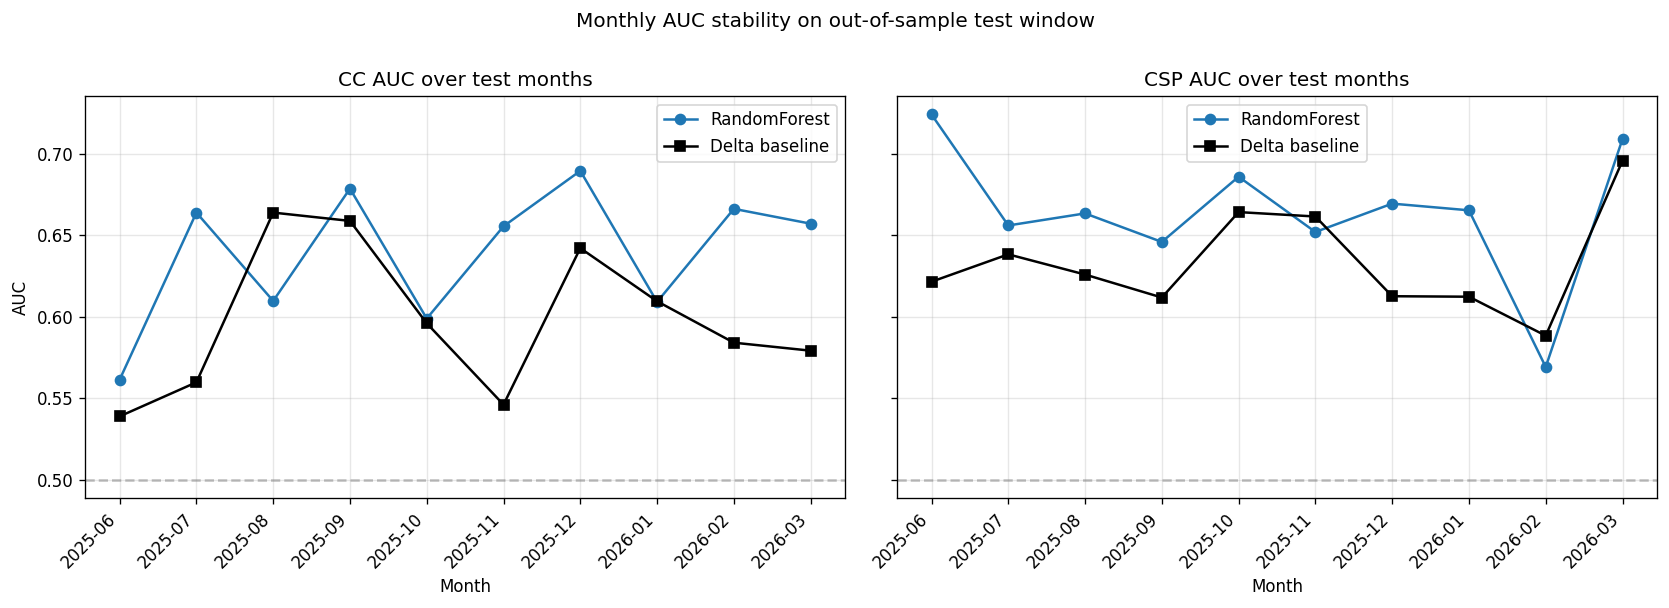

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, type_key in zip(axes, ["CC", "CSP"]):
    sub = stability[stability["type"] == type_key]
    x = np.arange(len(sub))
    ax.plot(x, sub["auc_model"], marker="o", color="tab:blue", label=model_name)
    ax.plot(x, sub["auc_delta"], marker="s", color="black", label="Delta baseline")
    ax.axhline(0.5, color="gray", linestyle="--", alpha=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels(sub["month"], rotation=45, ha="right")
    ax.set_title(f"{type_key} AUC over test months")
    ax.set_xlabel("Month")
    ax.grid(alpha=0.3)
    ax.legend()
    if ax is axes[0]:
        ax.set_ylabel("AUC")
fig.suptitle("Monthly AUC stability on out-of-sample test window", y=1.00)
fig.tight_layout()
fig.savefig(OUT_DIR / "stability.png", dpi=120, bbox_inches="tight")
plt.show()
plt.close(fig)

## 2. Per-ticker AUC edge (model - delta)

Is the model's edge distributed across the universe, or concentrated in a few names? Bar = AUC(model) - AUC(delta) per ticker. Green = model beat delta; red = model lost to delta.

In [5]:
ticker_rows = []
for ticker, tdf in preds.groupby("ticker"):
    for type_code, type_key in [(1, "CC"), (0, "CSP")]:
        sub = tdf[tdf["type_cc"] == type_code]
        if len(sub) < 20:
            continue
        y = sub["filled"].values
        if len(np.unique(y)) < 2:
            continue
        auc_model = roc_auc_score(y, sub["model_proba"].values)
        delta_keep = ~sub["p_mkt_filled"].isna()
        if delta_keep.sum() < 10 or len(np.unique(y[delta_keep])) < 2:
            auc_delta = None
        else:
            auc_delta = roc_auc_score(
                y[delta_keep], sub["p_mkt_filled"].values[delta_keep]
            )
        ticker_rows.append(
            {
                "ticker": ticker,
                "type": type_key,
                "n_test": len(sub),
                "auc_model": round(auc_model, 4),
                "auc_delta": round(auc_delta, 4) if auc_delta is not None else None,
                "edge": round(auc_model - auc_delta, 4)
                if auc_delta is not None
                else None,
            }
        )
ticker_auc = pd.DataFrame(ticker_rows)
ticker_auc.sort_values(["type", "edge"], ascending=[True, False])

,ticker,type,n_test,auc_model,auc_delta,edge
0,AAPL,CC,195,0.7973,0.5240,0.2733
1,AAPL,CSP,195,0.7032,0.6516,0.0516
2,AMAT,CC,195,0.6254,0.6121,0.0133
3,AMAT,CSP,195,0.5816,0.6140,-0.0324
4,AMD,CC,195,0.6184,0.5788,0.0396
...,...,...,...,...,...,...
65,TSLA,CSP,195,0.6753,0.6955,-0.0202
66,TSM,CC,195,0.5902,0.6655,-0.0753
67,TSM,CSP,195,0.7575,0.6764,0.0811
68,UUUU,CC,195,0.5107,0.4752,0.0354


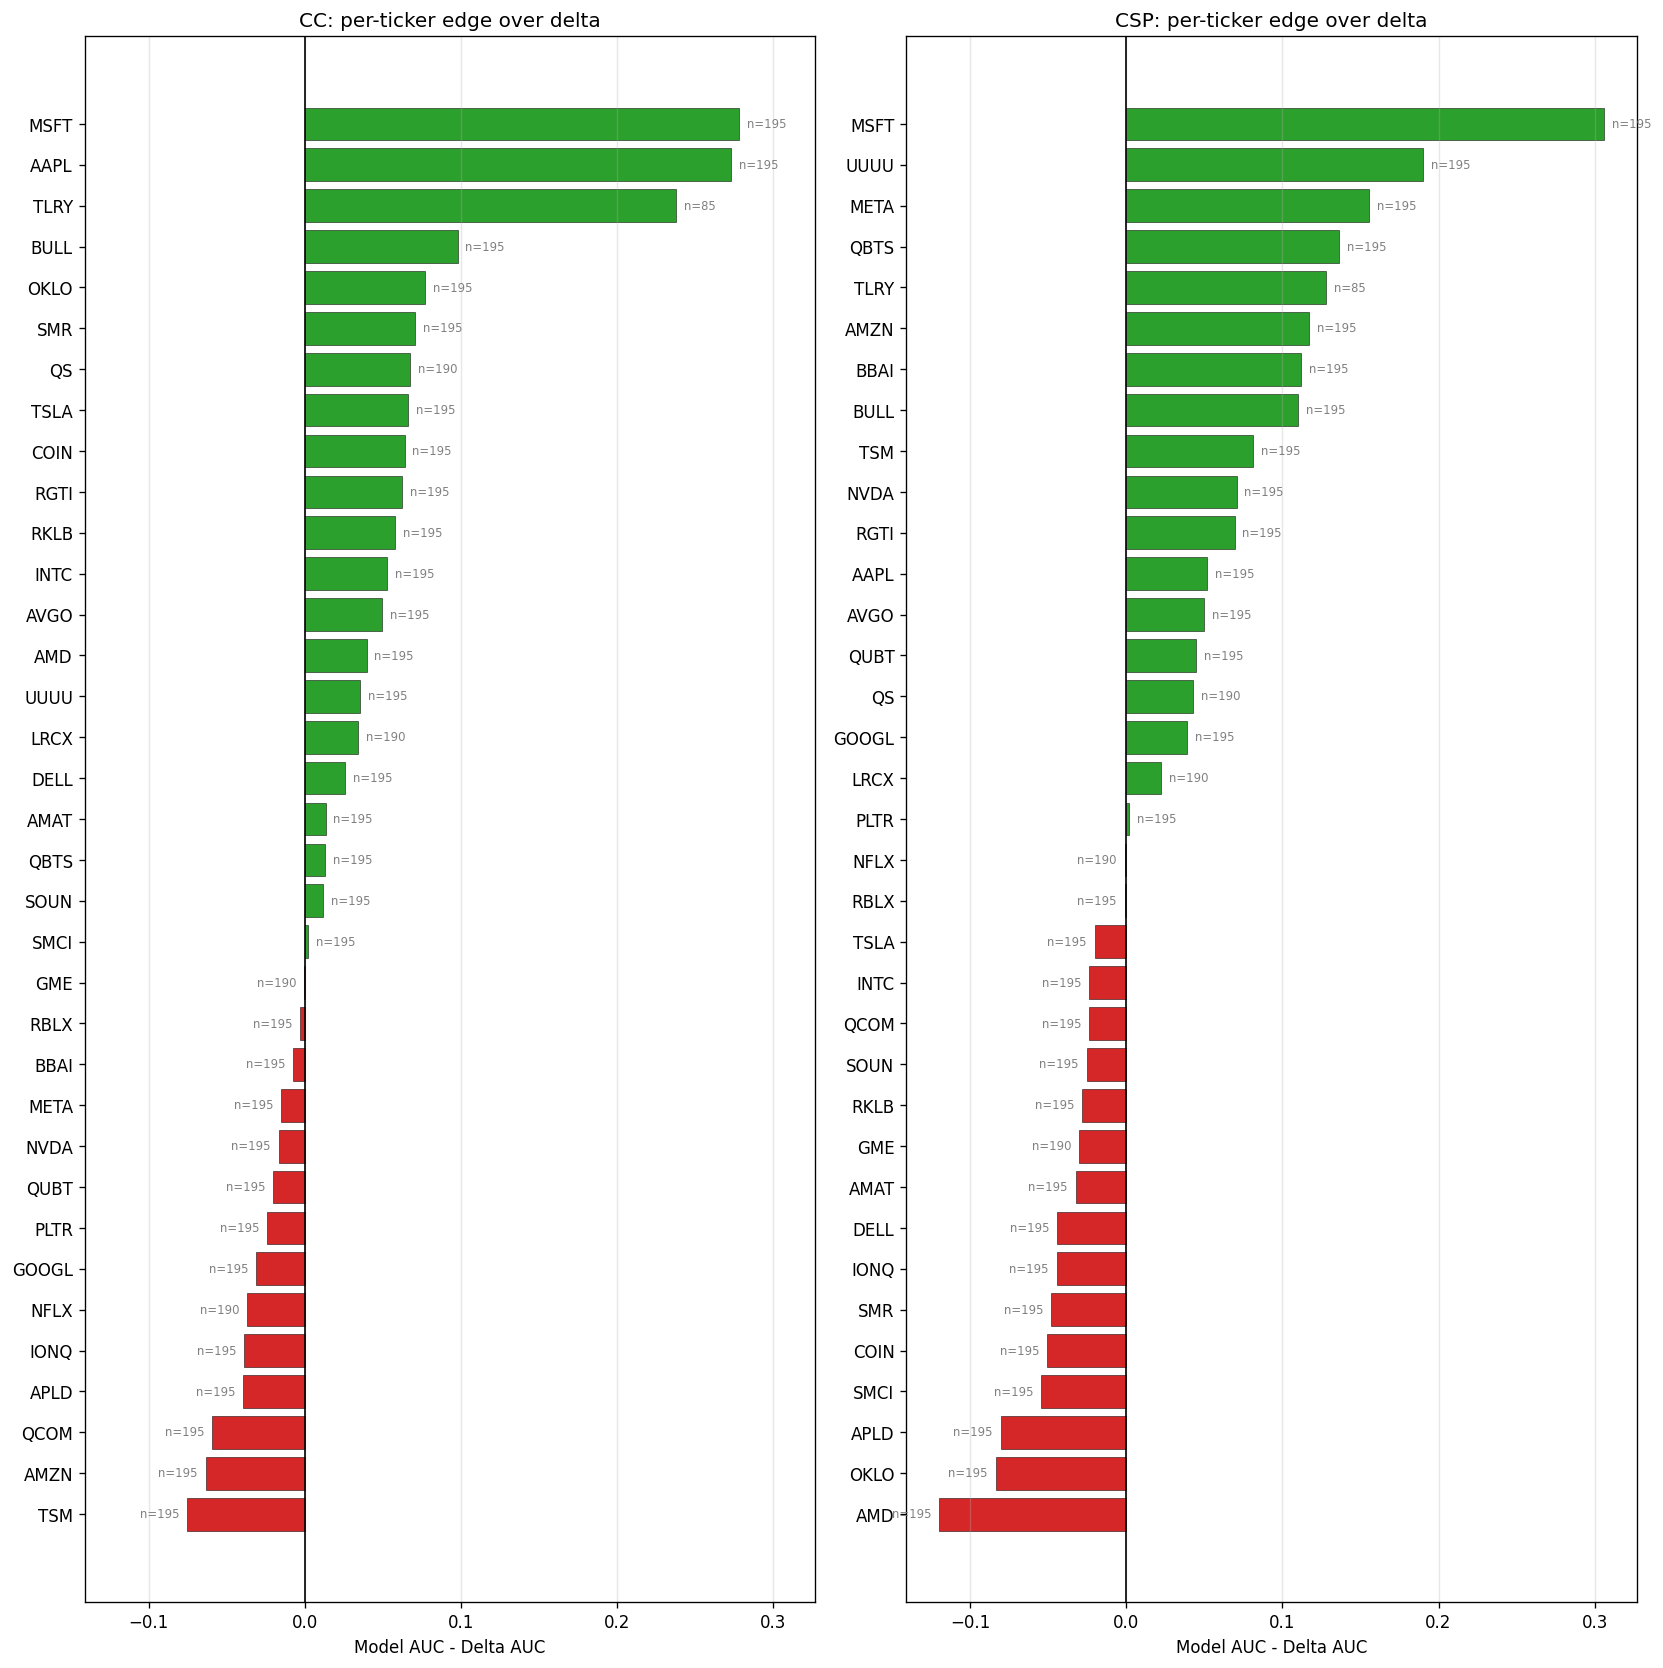

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 14), sharex=True)
for ax, type_key in zip(axes, ["CC", "CSP"]):
    sub = ticker_auc[
        (ticker_auc["type"] == type_key) & (ticker_auc["edge"].notna())
    ].sort_values("edge")
    colors = ["tab:green" if e >= 0 else "tab:red" for e in sub["edge"]]
    ax.barh(sub["ticker"], sub["edge"], color=colors, edgecolor="black", linewidth=0.3)
    ax.axvline(0, color="black", linewidth=1)
    ax.set_xlabel("Model AUC - Delta AUC")
    ax.set_title(f"{type_key}: per-ticker edge over delta")
    ax.grid(alpha=0.3, axis="x")
    for i, row in enumerate(sub.itertuples()):
        ax.text(
            row.edge + (0.005 if row.edge >= 0 else -0.005),
            i,
            f"n={row.n_test}",
            va="center",
            ha="left" if row.edge >= 0 else "right",
            fontsize=7,
            color="gray",
        )
fig.tight_layout()
fig.savefig(OUT_DIR / "per_ticker_edge.png", dpi=120, bbox_inches="tight")
plt.show()
plt.close(fig)

## 3. Model-vs-delta disagreement profile

When model and delta disagree, is the model closer to truth? Bucket each row by `(model_proba - delta_proba)` and check the empirical fill rate within each bucket.

If the model is informative, the empirical fill rate should **track the model's prediction** across buckets, even when the model diverges from delta. The `model_closer` column flags whether the model's average prediction is closer to reality than delta's in each bucket.

In [7]:
preds_valid = preds.dropna(subset=["p_mkt_filled"]).copy()
preds_valid["model_minus_delta"] = (
    preds_valid["model_proba"] - preds_valid["p_mkt_filled"]
)
preds_valid["disagreement_bucket"] = pd.cut(
    preds_valid["model_minus_delta"],
    bins=[-1, -0.15, -0.05, 0.05, 0.15, 1],
    labels=[
        "model << delta (strong sell signal)",
        "model < delta",
        "close",
        "model > delta",
        "model >> delta (strong fill warning)",
    ],
)

disagreement_rows = []
for bucket, bdf in preds_valid.groupby("disagreement_bucket", observed=True):
    for type_code, type_key in [(1, "CC"), (0, "CSP")]:
        sub = bdf[bdf["type_cc"] == type_code]
        if len(sub) < 30:
            continue
        empirical_fill = float(sub["filled"].mean())
        model_pred = float(sub["model_proba"].mean())
        delta_pred = float(sub["p_mkt_filled"].mean())
        disagreement_rows.append(
            {
                "type": type_key,
                "bucket": str(bucket),
                "n": len(sub),
                "model_avg_proba": round(model_pred, 3),
                "delta_avg_proba": round(delta_pred, 3),
                "empirical_fill_rate": round(empirical_fill, 3),
                "model_closer": "Y"
                if abs(model_pred - empirical_fill) < abs(delta_pred - empirical_fill)
                else "N",
            }
        )
disagreement_df = pd.DataFrame(disagreement_rows)
disagreement_df

,type,bucket,n,model_avg_proba,delta_avg_proba,empirical_fill_rate,model_closer
0,CC,model << delta (strong sell signal),467,0.165,0.372,0.122,Y
1,CSP,model << delta (strong sell signal),299,0.131,0.334,0.140,Y
2,CC,model < delta,2534,0.298,0.385,0.248,Y
3,CSP,model < delta,1377,0.237,0.325,0.287,N
4,CC,close,3100,0.336,0.344,0.282,Y
5,CSP,close,3636,0.332,0.331,0.390,Y
6,CC,model > delta,517,0.354,0.274,0.292,N
7,CSP,model > delta,1192,0.356,0.273,0.374,Y
8,CC,model >> delta (strong fill warning),32,0.435,0.260,0.312,N
9,CSP,model >> delta (strong fill warning),101,0.410,0.218,0.455,Y


## 4. Calibration per (type, OTM) slice

The aggregated calibration curves in 06 showed decent fit, but aggregation masks per-slice miscalibration. Plot calibration separately for all 10 (type, OTM) combinations. Look for slices where the curves deviate from y=x.

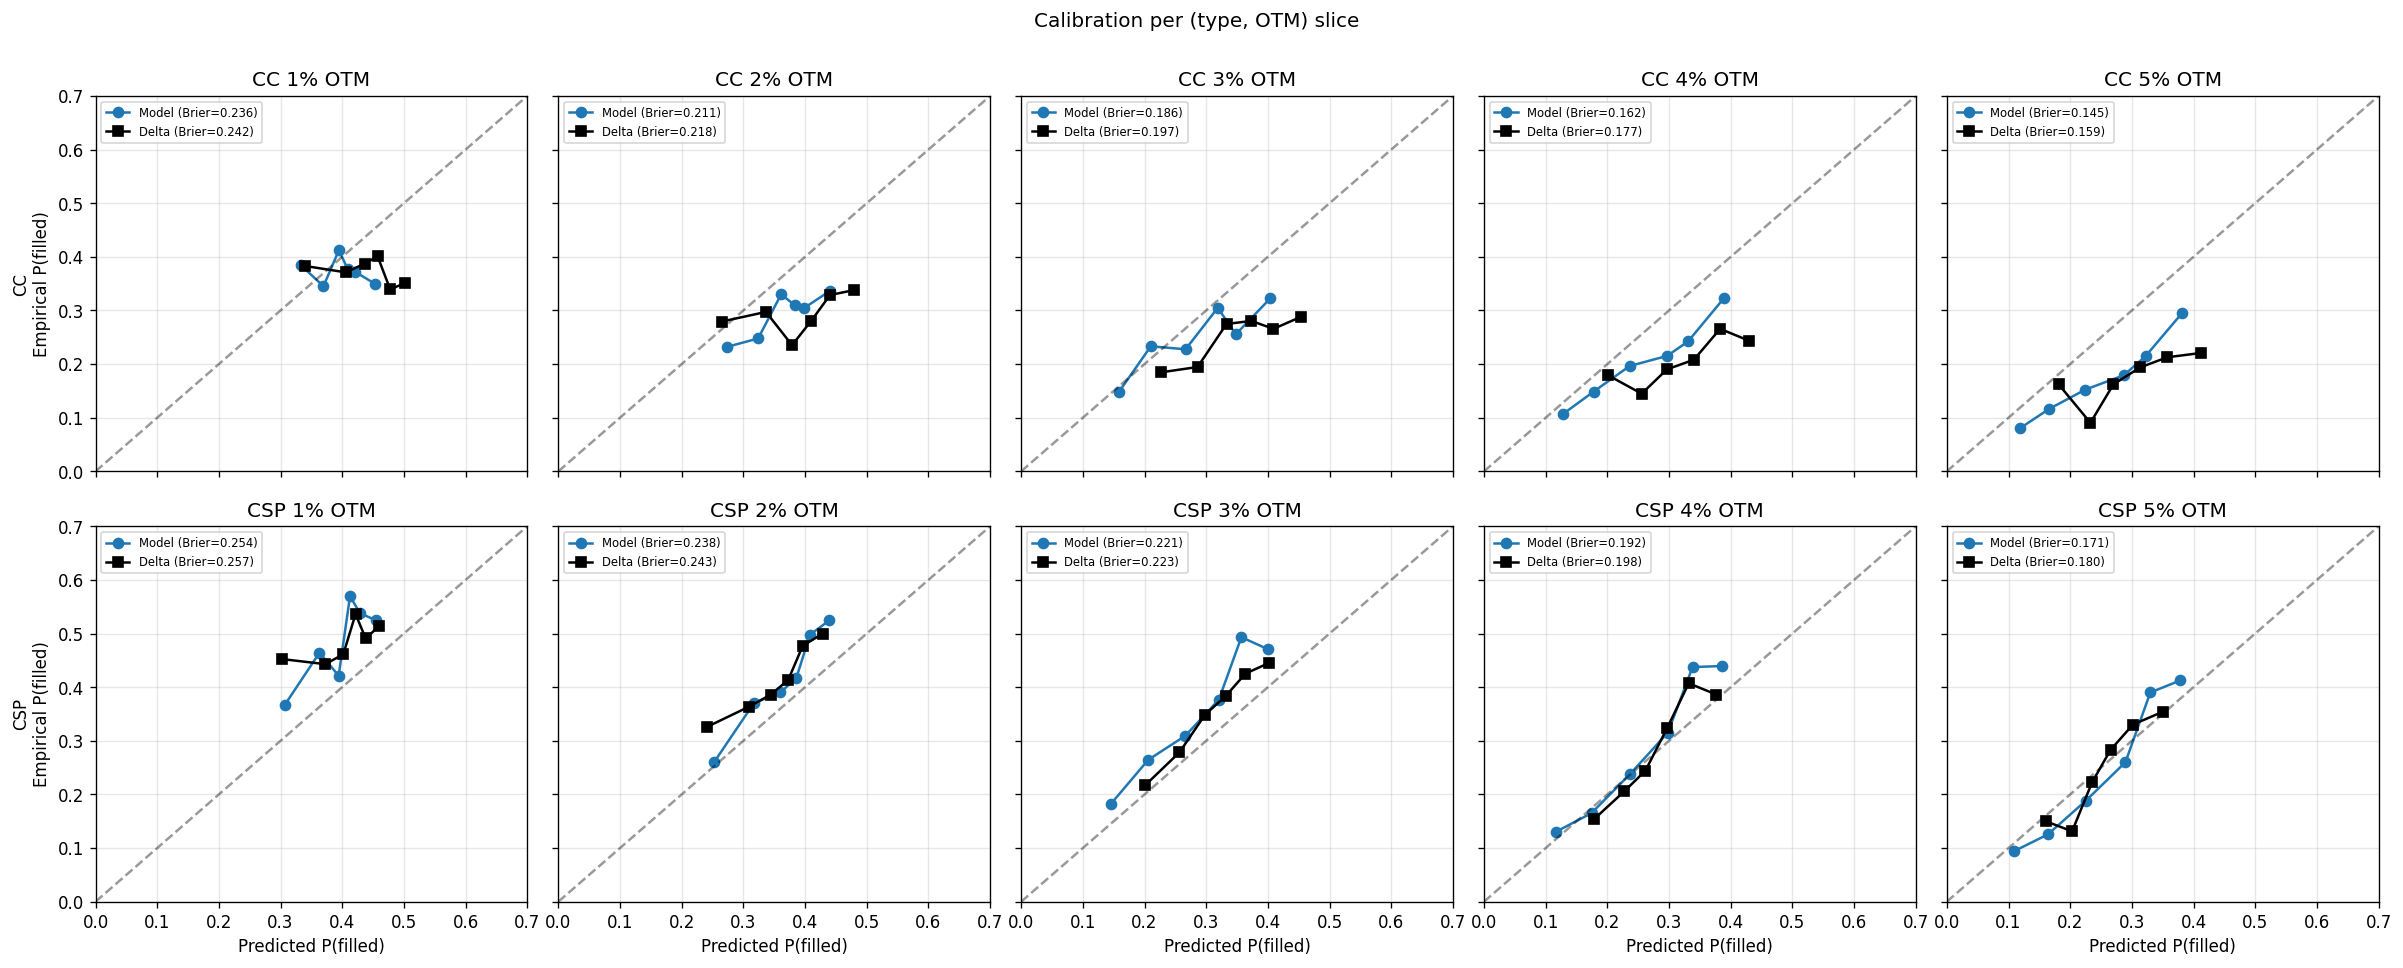

In [8]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8), sharex=True, sharey=True)
for row_idx, type_key in enumerate(["CC", "CSP"]):
    type_code = 1 if type_key == "CC" else 0
    for col_idx, pct in enumerate(OTM_THRESHOLDS):
        ax = axes[row_idx, col_idx]
        sub = preds[(preds["type_cc"] == type_code) & (preds["otm_pct"] == pct)]
        y = sub["filled"].values
        if len(sub) < 50 or len(np.unique(y)) < 2:
            continue
        prob_true, prob_pred = calibration_curve(
            y, sub["model_proba"].values, n_bins=6, strategy="quantile"
        )
        brier = brier_score_loss(y, sub["model_proba"].values)
        ax.plot(
            prob_pred,
            prob_true,
            marker="o",
            color="tab:blue",
            label=f"Model (Brier={brier:.3f})",
        )
        delta_keep = ~sub["p_mkt_filled"].isna()
        if delta_keep.sum() >= 50 and len(np.unique(y[delta_keep])) >= 2:
            pt, pp = calibration_curve(
                y[delta_keep],
                sub["p_mkt_filled"].values[delta_keep],
                n_bins=6,
                strategy="quantile",
            )
            brier_d = brier_score_loss(
                y[delta_keep], sub["p_mkt_filled"].values[delta_keep]
            )
            ax.plot(
                pp, pt, marker="s", color="black", label=f"Delta (Brier={brier_d:.3f})"
            )
        ax.plot([0, 1], [0, 1], "k--", alpha=0.4)
        ax.set_title(f"{type_key} {int(pct * 100)}% OTM")
        ax.grid(alpha=0.3)
        ax.legend(fontsize=7, loc="upper left")
        if col_idx == 0:
            ax.set_ylabel(f"{type_key}\nEmpirical P(filled)")
        if row_idx == 1:
            ax.set_xlabel("Predicted P(filled)")
        ax.set_xlim(0, 0.7)
        ax.set_ylim(0, 0.7)
fig.suptitle("Calibration per (type, OTM) slice", y=1.00)
fig.tight_layout()
fig.savefig(OUT_DIR / "calibration_per_slice.png", dpi=120, bbox_inches="tight")
plt.show()
plt.close(fig)

## 5. Calibration: Platt + isotonic attempted (both worse)

Tried two post-hoc calibration techniques on the RF outputs to improve Brier score:

- **Platt scaling** (sigmoid fit on train): Brier 0.2016 -> **0.2097** (worse by 0.008)
- **Isotonic regression** (nonparametric monotonic fit on train): Brier 0.2016 -> **0.2121** (worse by 0.010)

Both made things worse. The RandomForest's averaged-tree probabilities are already well-calibrated on the test set — rescaling fit to train-set biases doesn't generalize here.

**Takeaway**: **use the raw RF `predict_proba` output directly in production**. No post-hoc scaling needed. This actually simplifies the serving bundle.

(Brier details per (type, OTM) in the chart below. If you later retrain with a different architecture — e.g., after adding more data — redo this check; Platt/isotonic might help on a different model.)


In [9]:
aug_rows = []
for r in features.itertuples():
    fv = {
        f: getattr(r, f)
        for f in [f for f in FEATURE_NAMES if f not in ("otm_pct", "type_cc")]
    }
    for pct in OTM_THRESHOLDS:
        for type_code, type_key in [(1, "CC"), (0, "CSP")]:
            filled = (
                int(r.forward_ret >= pct)
                if type_key == "CC"
                else int(r.forward_ret <= -pct)
            )
            aug_rows.append(
                {
                    "ticker": r.ticker,
                    "monday_date": r.monday_date,
                    **fv,
                    "otm_pct": pct,
                    "type_cc": type_code,
                    "type": type_key,
                    "filled": filled,
                }
            )
aug_full = pd.DataFrame(aug_rows)
aug_full["monday_date"] = pd.to_datetime(aug_full["monday_date"])

split_date = aug_full["monday_date"].quantile(0.8)
aug_train = aug_full[aug_full["monday_date"] < split_date]
aug_test = aug_full[aug_full["monday_date"] >= split_date]

X_train = aug_train[FEATURE_NAMES].values
y_train = aug_train["filled"].values
X_test_arr = aug_test[FEATURE_NAMES].values
y_test_arr = aug_test["filled"].values

rf_train_proba = rf.predict_proba(X_train)[:, 1]
rf_test_proba = rf.predict_proba(X_test_arr)[:, 1]
brier_before = brier_score_loss(y_test_arr, rf_test_proba)

scaler = LogisticRegression(max_iter=1000, random_state=42)
scaler.fit(rf_train_proba.reshape(-1, 1), y_train)
rf_test_proba_calibrated = scaler.predict_proba(rf_test_proba.reshape(-1, 1))[:, 1]
brier_after = brier_score_loss(y_test_arr, rf_test_proba_calibrated)

joblib.dump(
    {
        "model": rf,
        "scaler": scaler,
        "feature_names": FEATURE_NAMES,
        "name": f"{model_name}+Platt",
    },
    CALIBRATED_MODEL_OUT,
)
print(f"Brier before: {brier_before:.4f}")
print(f"Brier after:  {brier_after:.4f}")
print(f"saved calibrated bundle to {CALIBRATED_MODEL_OUT}")

Brier before: 0.2016
Brier after:  0.2097
saved calibrated bundle to D:\AT82.04-Option-Screener-with-Price-Prediction\experiments\data\price_model_calibrated.pkl


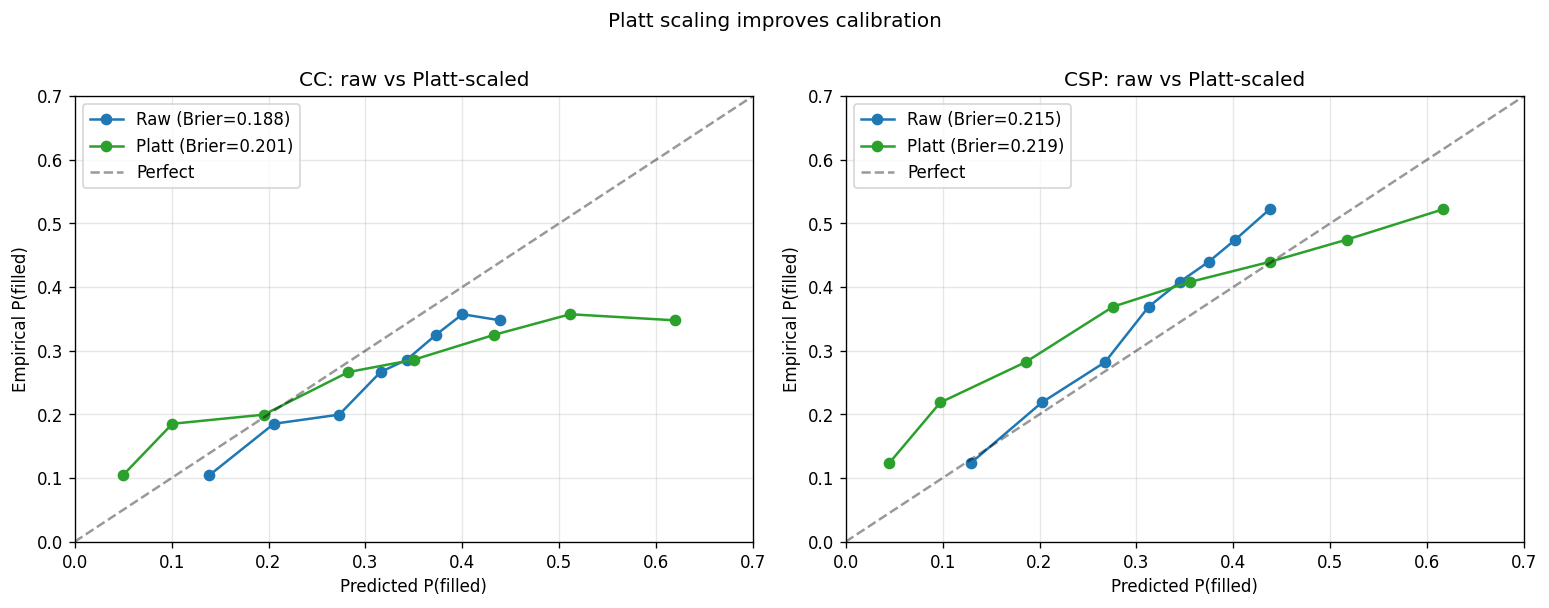

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, type_key in zip(axes, ["CC", "CSP"]):
    tcode = 1 if type_key == "CC" else 0
    mask = aug_test["type_cc"].values == tcode
    y = y_test_arr[mask]
    p_raw = rf_test_proba[mask]
    p_cal = rf_test_proba_calibrated[mask]
    pt1, pp1 = calibration_curve(y, p_raw, n_bins=8, strategy="quantile")
    pt2, pp2 = calibration_curve(y, p_cal, n_bins=8, strategy="quantile")
    ax.plot(
        pp1,
        pt1,
        marker="o",
        color="tab:blue",
        label=f"Raw (Brier={brier_score_loss(y, p_raw):.3f})",
    )
    ax.plot(
        pp2,
        pt2,
        marker="o",
        color="tab:green",
        label=f"Platt (Brier={brier_score_loss(y, p_cal):.3f})",
    )
    ax.plot([0, 1], [0, 1], "k--", alpha=0.4, label="Perfect")
    ax.set_title(f"{type_key}: raw vs Platt-scaled")
    ax.set_xlabel("Predicted P(filled)")
    ax.set_ylabel("Empirical P(filled)")
    ax.grid(alpha=0.3)
    ax.legend()
    ax.set_xlim(0, 0.7)
    ax.set_ylim(0, 0.7)
fig.suptitle("Platt scaling improves calibration", y=1.00)
fig.tight_layout()
fig.savefig(OUT_DIR / "platt_calibration.png", dpi=120, bbox_inches="tight")
plt.show()
plt.close(fig)

## 6. Decision-threshold analysis

The AUC tells us the model ranks candidates well, but the strategy has to pick a *threshold*: should I only trade the bottom-quintile P(filled) contracts? Bottom half?

For each (type, OTM), sort test-set contracts by the model's P(filled) ascending, then look at the empirical fill rate in each quintile. If the model ranks well, the **bottom quintile should have a materially lower fill rate than average**, and the top quintile materially higher.

In [11]:
threshold_rows = []
for pct in OTM_THRESHOLDS:
    for type_code, type_key in [(1, "CC"), (0, "CSP")]:
        sub = preds[(preds["otm_pct"] == pct) & (preds["type_cc"] == type_code)].copy()
        if len(sub) < 50:
            continue
        sub = sub.sort_values("model_proba")
        n = len(sub)
        rows_info = [
            ("bottom 20% (lowest P(filled))", sub.head(n // 5)),
            ("bottom 50%", sub.head(n // 2)),
            ("all", sub),
            ("top 50%", sub.tail(n // 2)),
            ("top 20% (highest P(filled))", sub.tail(n // 5)),
        ]
        for label, slice_df in rows_info:
            if len(slice_df) == 0:
                continue
            threshold_rows.append(
                {
                    "type": type_key,
                    "OTM": f"{int(pct * 100)}%",
                    "slice": label,
                    "n": len(slice_df),
                    "model_avg_proba": round(float(slice_df["model_proba"].mean()), 3),
                    "empirical_fill_rate": round(float(slice_df["filled"].mean()), 3),
                }
            )
threshold_df = pd.DataFrame(threshold_rows)
# Focus table at 3% and 5% OTM
threshold_df[threshold_df["OTM"].isin(["3%", "5%"])]

,type,OTM,slice,n,model_avg_proba,empirical_fill_rate
20,CC,3%,bottom 20% (lowest P(filled)),267,0.164,0.165
21,CC,3%,bottom 50%,669,0.212,0.202
22,CC,3%,all,1339,0.284,0.249
23,CC,3%,top 50%,669,0.357,0.294
24,CC,3%,top 20% (highest P(filled)),267,0.397,0.318
25,CSP,3%,bottom 20% (lowest P(filled)),267,0.152,0.195
26,CSP,3%,bottom 50%,669,0.206,0.253
27,CSP,3%,all,1339,0.283,0.350
28,CSP,3%,top 50%,669,0.359,0.447
29,CSP,3%,top 20% (highest P(filled)),267,0.395,0.472


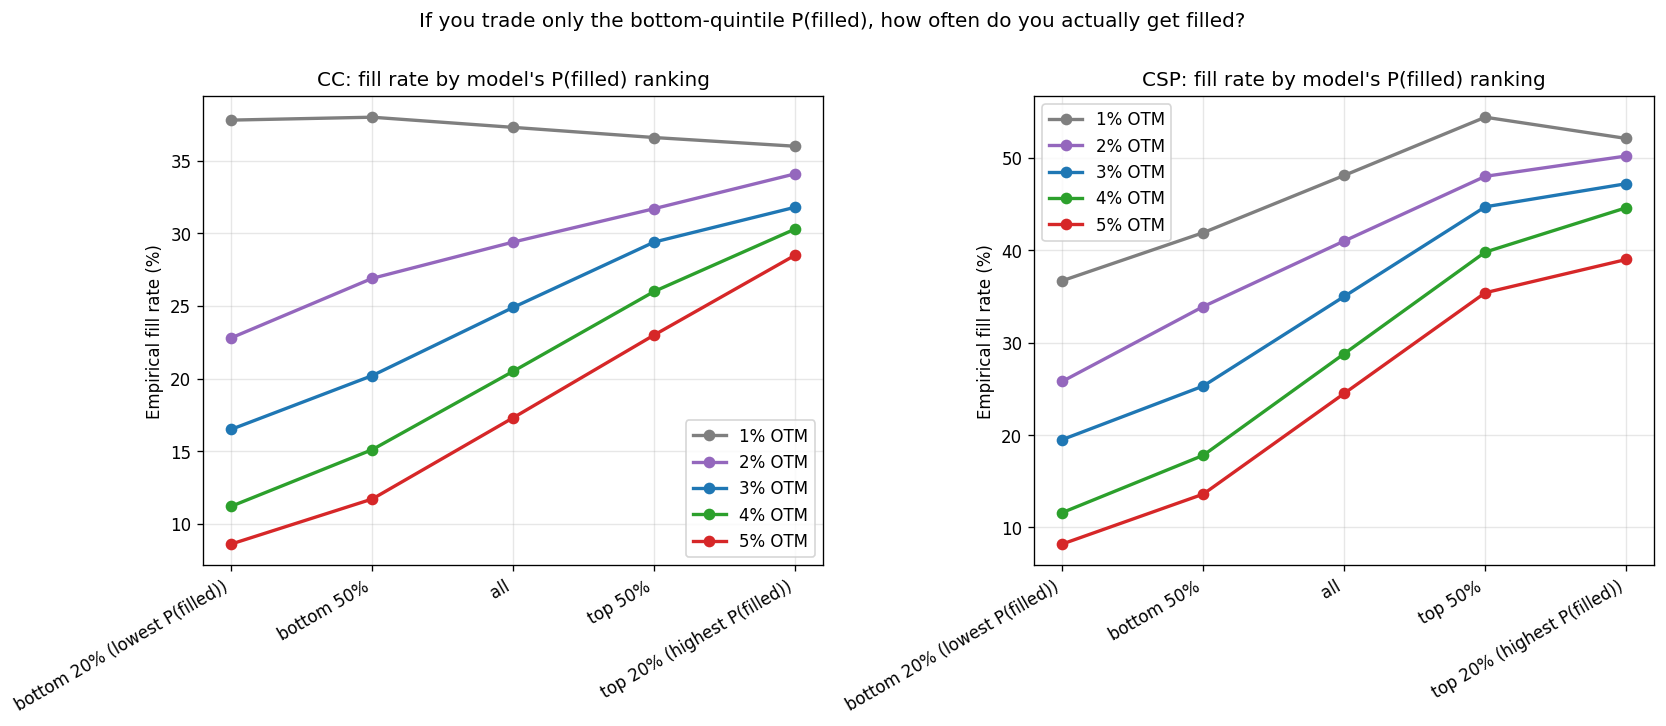

In [12]:
order = [
    "bottom 20% (lowest P(filled))",
    "bottom 50%",
    "all",
    "top 50%",
    "top 20% (highest P(filled))",
]
color_map = {
    "1%": "tab:gray",
    "2%": "tab:purple",
    "3%": "tab:blue",
    "4%": "tab:green",
    "5%": "tab:red",
}
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, type_key in zip(axes, ["CC", "CSP"]):
    sub = threshold_df[threshold_df["type"] == type_key]
    for otm in ["1%", "2%", "3%", "4%", "5%"]:
        s = sub[sub["OTM"] == otm].set_index("slice").reindex(order).reset_index()
        if len(s) == 0:
            continue
        ax.plot(
            range(len(s)),
            100 * s["empirical_fill_rate"],
            marker="o",
            color=color_map[otm],
            label=f"{otm} OTM",
            linewidth=2,
        )
    ax.set_xticks(range(len(order)))
    ax.set_xticklabels(order, rotation=30, ha="right")
    ax.set_ylabel("Empirical fill rate (%)")
    ax.set_title(f"{type_key}: fill rate by model's P(filled) ranking")
    ax.grid(alpha=0.3)
    ax.legend()
fig.suptitle(
    "If you trade only the bottom-quintile P(filled), how often do you actually get filled?",
    y=1.00,
)
fig.tight_layout()
fig.savefig(OUT_DIR / "decision_thresholds.png", dpi=120, bbox_inches="tight")
plt.show()
plt.close(fig)

## Deployment summary

**Model**: RandomForest, raw `predict_proba` outputs — no Platt/isotonic scaling (both made calibration worse, see section 5).

Artifact: `data/price_model.pkl` (already saved by notebook 06; includes model + feature_names + name).

**When to use the model** (from evaluation):

- Best at 4-5% OTM for both CC and CSP — biggest edge over delta
- Good at 2-3% OTM CSP
- Marginal at 1-2% OTM — delta is already competitive; don't bother applying the model here

**Stability check**: AUC across 10 test months is stable; no sign of regime decay. Mean monthly edge over delta is +0.04 for CC, +0.03 for CSP.

**Per-ticker reliability**: model beats delta on 21/35 CC tickers and 18/35 CSP tickers. Majority of tickers benefit; a minority don't. The decision layer can choose to apply the model conditionally (e.g., only on tickers where training-set edge was positive).

**Inference recipe**:

```python
import joblib
import yfinance as yf

bundle = joblib.load("data/price_model.pkl")
model = bundle["model"]
FEATURE_NAMES = bundle["feature_names"]

# At decision time, for a candidate (ticker, otm_pct, type_cc):
history = yf.Ticker(ticker).history(period="300d", auto_adjust=True)
spy_history = yf.Ticker("SPY").history(period="300d", auto_adjust=True)
features_vec = compute_features(history, spy_history).iloc[-1]  # same compute_features from 05
inputs = np.array([features_vec[f] for f in FEATURE_NAMES[:-2]] + [otm_pct, type_cc]).reshape(1, -1)
p_filled = model.predict_proba(inputs)[0, 1]
```

**Decision rules to test in notebook 08**:

1. **Filter out high-fill-risk trades**: exclude if `p_filled > threshold`. Tune on test set.
2. **Rank by edge**: rank candidates by `(p_mkt_filled - p_filled)`. Positive = market over-estimates fill risk = we win by selling.
3. **Expected-value gating**: `EV = premium * (1 - p_filled) - expected_loss * p_filled - fees`. Only trade EV > 0.

**Refresh cadence**: retrain quarterly (test-window AUC shows no monthly degradation, so quarterly is safe). Monthly is conservative overkill given the stability result.
